In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.facecolor' : '#ffffff',
    'axes.facecolor'   : '#f8f9fa',
    'axes.edgecolor'   : '#dee2e6',
    'axes.labelcolor'  : '#495057',
    'text.color'       : '#212529',
    'xtick.color'      : '#6c757d',
    'ytick.color'      : '#6c757d',
    'grid.color'       : '#e9ecef',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
events = pd.read_csv('../data/events.csv',
                     parse_dates=['event_timestamp'])
pre    = pd.read_csv('../data/pre_exp_sessions.csv',
                     parse_dates=['session_start','session_end'])
exp    = pd.read_csv('../data/exp_sessions.csv',
                     parse_dates=['session_start','session_end'])

EXP_START = pd.Timestamp('2024-01-08')
OBS_START = pd.Timestamp('2023-04-01')

pre_events = events[events['event_timestamp'] < EXP_START].copy()

print(f"Pre-experiment sessions:  {len(pre):,}")
print(f"Experiment sessions:      {len(exp):,}")
print(f"Pre-experiment events:    {len(pre_events):,}")
print(f"\nDate range:")
print(f"  Pre-exp: {pre['session_start'].min().date()} → "
      f"{pre['session_start'].max().date()}")
print(f"  Exp:     {exp['session_start'].min().date()} → "
      f"{exp['session_start'].max().date()}")

Pre-experiment sessions:  29,122
Experiment sessions:      16,555
Pre-experiment events:    63,659

Date range:
  Pre-exp: 2023-04-01 → 2023-12-30
  Exp:     2024-01-08 → 2024-04-06


In [3]:
print("=" * 65)
print("SECTION 1 — ACQUISITION COHORT RETENTION")
print("=" * 65)
print("""
Groups users by the month they FIRST visited the site.
Tracks what % of each cohort returned in subsequent months.

Key question: Is the retention problem consistent across
all acquisition cohorts, or are some months better?

If flat across cohorts → structural problem
  (the site itself does not retain users well)
If some cohorts retain better → campaign-specific
  (certain acquisition campaigns bring better users)

This matters because:
  Structural problem → fix the product / retention mechanics
  Campaign problem   → fix the acquisition channel / targeting
""")

SECTION 1 — ACQUISITION COHORT RETENTION

Groups users by the month they FIRST visited the site.
Tracks what % of each cohort returned in subsequent months.

Key question: Is the retention problem consistent across
all acquisition cohorts, or are some months better?

If flat across cohorts → structural problem
  (the site itself does not retain users well)
If some cohorts retain better → campaign-specific
  (certain acquisition campaigns bring better users)

This matters because:
  Structural problem → fix the product / retention mechanics
  Campaign problem   → fix the acquisition channel / targeting



In [4]:
# Assign each event to a month period
pre_events['month'] = pre_events['event_timestamp'].dt.to_period('M')

# Find first visit month per user
user_first_month = (
    pre_events.groupby('user_pseudo_id')['month']
    .min()
    .reset_index()
    .rename(columns={'month': 'cohort_month'})
)

# Monthly activity per user
user_monthly_activity = (
    pre_events.groupby(['user_pseudo_id','month'])
    .size()
    .reset_index(name='event_count')
)

# Join cohort month
cohort_data = user_monthly_activity.merge(
    user_first_month, on='user_pseudo_id', how='left'
)

# Compute period number (months since first visit)
cohort_data['period_number'] = (
    cohort_data['month'] - cohort_data['cohort_month']
).apply(lambda x: x.n)

# Cohort size (period 0 = acquisition month)
cohort_counts = (
    cohort_data.groupby(['cohort_month','period_number'])
    ['user_pseudo_id'].nunique()
    .reset_index(name='users')
)

# Pivot to matrix
cohort_matrix = cohort_counts.pivot_table(
    index='cohort_month',
    columns='period_number',
    values='users'
)

# Cohort sizes (period 0)
cohort_sizes = cohort_matrix[0]

# Retention rates
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

# Convert index to string for plotting
cohort_matrix.index    = cohort_matrix.index.astype(str)
retention_matrix.index = retention_matrix.index.astype(str)

print(f"Cohorts tracked: {len(retention_matrix)}")
print(f"Max periods:     {retention_matrix.shape[1]}")
print(f"\nCohort sizes:")
for month, size in cohort_sizes.items():
    print(f"  {str(month)}: {int(size):,} users")

print(f"\nAvg retention by period:")
avg_ret = retention_matrix.mean()
for period in range(min(7, len(avg_ret))):
    print(f"  Month {period}: {avg_ret.iloc[period]:.1%}")

Cohorts tracked: 8
Max periods:     6

Cohort sizes:
  2023-04: 1,740 users
  2023-05: 1,713 users
  2023-06: 1,597 users
  2023-07: 1,799 users
  2023-08: 1,685 users
  2023-09: 1,657 users
  2023-10: 1,748 users
  2023-11: 61 users

Avg retention by period:
  Month 0: 100.0%
  Month 1: 57.1%
  Month 2: 34.1%
  Month 3: 14.9%
  Month 4: 4.8%
  Month 5: 0.8%


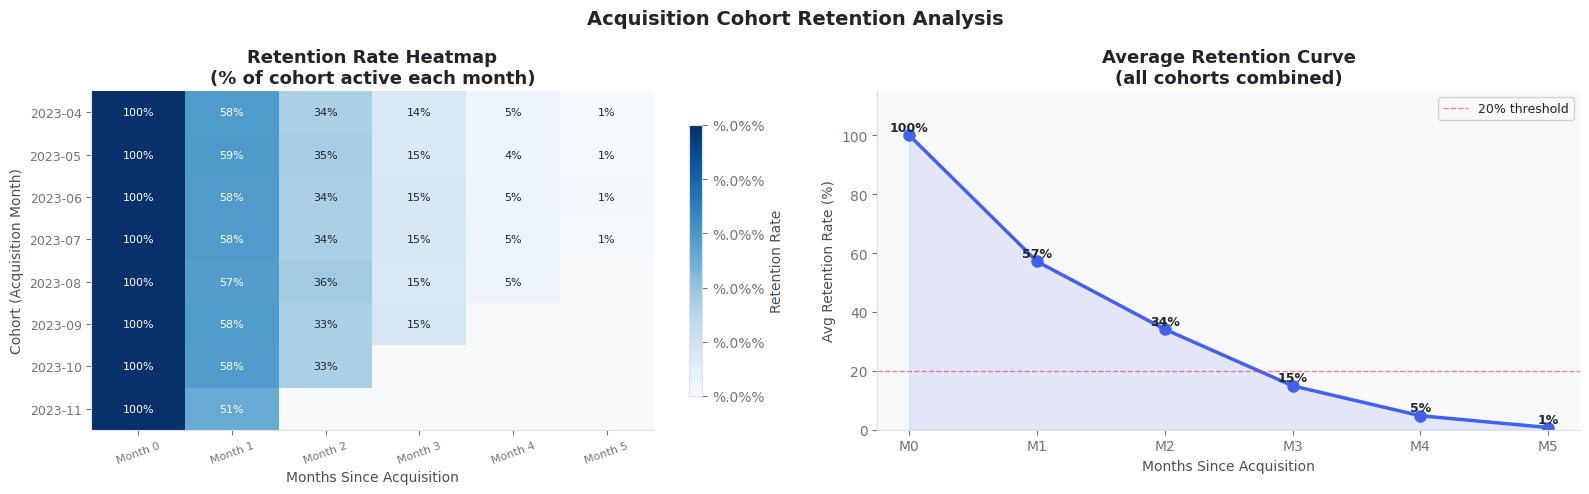

Average retention:
  Month 1: 57.1%
  Month 3: 14.9%
  Month 6: 0.0%

Month-1 retention coefficient of variation: 0.045
✓ Flat across cohorts (CV < 0.15) → structural problem


In [5]:
max_periods = min(9, retention_matrix.shape[1])
plot_matrix = retention_matrix.iloc[:, :max_periods].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Acquisition Cohort Retention Analysis',
             fontsize=14, fontweight='bold')

# ── Left: retention heatmap ────────────────────────────────────────────
ax = axes[0]
z_vals    = plot_matrix.values.astype(float)
x_labels  = [f'Month {i}' for i in range(max_periods)]
text_vals = [[f'{v:.0%}' if not np.isnan(v) else ''
              for v in row] for row in z_vals]

im = ax.imshow(z_vals, cmap='Blues', aspect='auto',
               vmin=0, vmax=1)

ax.set_xticks(range(max_periods))
ax.set_xticklabels(x_labels, fontsize=8, rotation=20)
ax.set_yticks(range(len(plot_matrix.index)))
ax.set_yticklabels(plot_matrix.index.tolist(), fontsize=9)
ax.set_xlabel('Months Since Acquisition')
ax.set_ylabel('Cohort (Acquisition Month)')
ax.set_title('Retention Rate Heatmap\n(% of cohort active each month)')

for i in range(len(plot_matrix.index)):
    for j in range(max_periods):
        val = z_vals[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.5 else '#212529'
            ax.text(j, i, f'{val:.0%}',
                    ha='center', va='center',
                    fontsize=8, color=color)

plt.colorbar(im, ax=ax, label='Retention Rate',
             shrink=0.8, format='%.0%%')

# ── Right: average retention curve ────────────────────────────────────
ax2 = axes[1]
avg_ret = plot_matrix.mean()
periods = list(range(max_periods))

ax2.plot(periods, avg_ret.values*100,
         marker='o', linewidth=2.5,
         color='#4361ee', markersize=8)
ax2.fill_between(periods, avg_ret.values*100,
                 alpha=0.12, color='#4361ee')

for i, (period, val) in enumerate(zip(periods, avg_ret.values)):
    if not np.isnan(val):
        ax2.text(period, val*100+1.5, f'{val:.0%}',
                 ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Months Since Acquisition')
ax2.set_ylabel('Avg Retention Rate (%)')
ax2.set_title('Average Retention Curve\n(all cohorts combined)')
ax2.set_xticks(periods)
ax2.set_xticklabels([f'M{p}' for p in periods])
ax2.set_ylim(0, 115)
ax2.axhline(20, color='#e63946', linestyle='--',
            linewidth=1, alpha=0.6, label='20% threshold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/cohort_retention_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Key stats
m1_ret = avg_ret.iloc[1] if len(avg_ret) > 1 else 0
m3_ret = avg_ret.iloc[3] if len(avg_ret) > 3 else 0
m6_ret = avg_ret.iloc[6] if len(avg_ret) > 6 else 0

print(f"Average retention:")
print(f"  Month 1: {m1_ret:.1%}")
print(f"  Month 3: {m3_ret:.1%}")
print(f"  Month 6: {m6_ret:.1%}")

# Check if flat across cohorts
m1_by_cohort = retention_matrix.iloc[:,1].dropna()
cv = m1_by_cohort.std() / m1_by_cohort.mean()
print(f"\nMonth-1 retention coefficient of variation: {cv:.3f}")
print(f"{'✓ Flat across cohorts (CV < 0.15) → structural problem' if cv < 0.15 else '→ Variation across cohorts — check acquisition quality'}")

In [6]:
print("=" * 65)
print("SECTION 2 — BEHAVIORAL COHORT SEGMENTATION (ENRICHED)")
print("=" * 65)
print("""
Groups PDP visitors by HOW they engaged with the page.

v1 (original): 3 cohorts based on PDP views + ATC status
v2 (new):      Now enriched with scroll depth + intent level

Cohort A: Single PDP view, did not ATC
  → Minimal engagement — likely wrong_audience or impulse_faded

Cohort B: Repeat PDP viewer (2+), did not ATC
  → High intent, no conversion — DECISION FRICTION TARGET
  → This is the exact population the A/B treatment targets

Cohort C: Added to Cart
  → Committed buyers — high CVR expected

New dimensions added:
  → Avg scroll depth per cohort
  → Intent level distribution per cohort
  → Drop-off reason distribution per cohort
  These three together paint a richer picture of
  WHO is in each cohort and WHY they behave differently
""")

SECTION 2 — BEHAVIORAL COHORT SEGMENTATION (ENRICHED)

Groups PDP visitors by HOW they engaged with the page.

v1 (original): 3 cohorts based on PDP views + ATC status
v2 (new):      Now enriched with scroll depth + intent level

Cohort A: Single PDP view, did not ATC
  → Minimal engagement — likely wrong_audience or impulse_faded

Cohort B: Repeat PDP viewer (2+), did not ATC
  → High intent, no conversion — DECISION FRICTION TARGET
  → This is the exact population the A/B treatment targets

Cohort C: Added to Cart
  → Committed buyers — high CVR expected

New dimensions added:
  → Avg scroll depth per cohort
  → Intent level distribution per cohort
  → Drop-off reason distribution per cohort
  These three together paint a richer picture of
  WHO is in each cohort and WHY they behave differently



In [7]:
pdp_sessions = pre[pre['reached_pdp']==True].copy()

def assign_behavioral_cohort(row):
    if row['reached_atc']:
        return 'C_atc_user'
    elif row['pdp_view_count'] >= 2:
        return 'B_repeat_viewer'
    else:
        return 'A_single_viewer'

pdp_sessions['cohort'] = pdp_sessions.apply(
    assign_behavioral_cohort, axis=1)

# Core metrics per cohort
cohort_metrics = (
    pdp_sessions.groupby('cohort')
    .agg(
        users             = ('cohort',             'count'),
        purchased         = ('purchased',           'sum'),
        reached_checkout  = ('reached_checkout',   'sum'),
        avg_pdp_views     = ('pdp_view_count',     'mean'),
        avg_scroll        = ('avg_scroll_depth',   'mean'),
        avg_dur_sec       = ('session_duration_sec','mean'),
    )
    .reset_index()
)

cohort_metrics['cvr']           = cohort_metrics['purchased']       / cohort_metrics['users']
cohort_metrics['checkout_rate'] = cohort_metrics['reached_checkout']/ cohort_metrics['users']
cohort_metrics['avg_dur_min']   = cohort_metrics['avg_dur_sec'] / 60
cohort_metrics['pct_of_pdp']    = cohort_metrics['users'] / len(pdp_sessions)

label_map = {
    'A_single_viewer': 'A: Single PDP View',
    'B_repeat_viewer': 'B: Repeat PDP Viewer (2+)',
    'C_atc_user'     : 'C: Added to Cart',
}
cohort_metrics['label'] = cohort_metrics['cohort'].map(label_map)
cohort_metrics = cohort_metrics.sort_values('cohort')

print("Behavioral cohort summary:")
display(cohort_metrics[[
    'label','users','pct_of_pdp','cvr','checkout_rate',
    'avg_pdp_views','avg_scroll','avg_dur_min'
]].round(3))

# Intent level distribution per cohort
print("\nIntent level distribution by cohort:")
intent_by_cohort = (
    pdp_sessions.groupby(['cohort','intent_level'])
    .size().reset_index(name='count')
)
cohort_totals = pdp_sessions.groupby('cohort').size()
intent_by_cohort['pct'] = intent_by_cohort.apply(
    lambda r: r['count']/cohort_totals[r['cohort']], axis=1)
intent_pivot = intent_by_cohort.pivot(
    index='cohort', columns='intent_level', values='pct'
).fillna(0)[['very_low','low','medium','high','very_high']]
display(intent_pivot.round(3))

# Drop-off reason distribution per cohort (A and B only)
print("\nDrop-off reason distribution (non-ATC cohorts):")
non_atc = pdp_sessions[pdp_sessions['cohort'].isin(
    ['A_single_viewer','B_repeat_viewer'])].copy()
reason_by_cohort = (
    non_atc.groupby(['cohort','dropoff_reason'])
    .size().reset_index(name='count')
)
non_atc_totals = non_atc.groupby('cohort').size()
reason_by_cohort['pct'] = reason_by_cohort.apply(
    lambda r: r['count']/non_atc_totals[r['cohort']], axis=1)
reason_pivot = reason_by_cohort.pivot(
    index='cohort', columns='dropoff_reason', values='pct'
).fillna(0)
display(reason_pivot.round(3))

Behavioral cohort summary:


,label,users,pct_of_pdp,cvr,checkout_rate,avg_pdp_views,avg_scroll,avg_dur_min
0,A: Single PDP View,3214,0.4100,0.0000,0.0000,1.0000,0.2970,1.4640
1,B: Repeat PDP Viewer (2+),1484,0.1890,0.0000,0.0000,2.4010,0.7350,5.3430
2,C: Added to Cart,3138,0.4000,0.4520,0.5420,1.5580,0.7230,4.7150



Intent level distribution by cohort:


intent_level,very_low,low,medium,high,very_high
cohort,,,,,
A_single_viewer,0.0120,0.2160,0.0470,0.2190,0.5060
B_repeat_viewer,0.0000,0.0030,0.0580,0.5590,0.3800
C_atc_user,0.0010,0.0280,0.0180,0.3260,0.6270



Drop-off reason distribution (non-ATC cohorts):


dropoff_reason,ad_pdp_mismatch,comparison_intent,converted,decision_friction,distraction,impulse_faded,out_of_stock,price_barrier,price_shock,wrong_audience
cohort,,,,,,,,,,
A_single_viewer,0.0160,0.0830,0.0820,0.0000,0.1300,0.0690,0.1100,0.3900,0.0750,0.0440
B_repeat_viewer,0.0000,0.2780,0.1210,0.6020,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


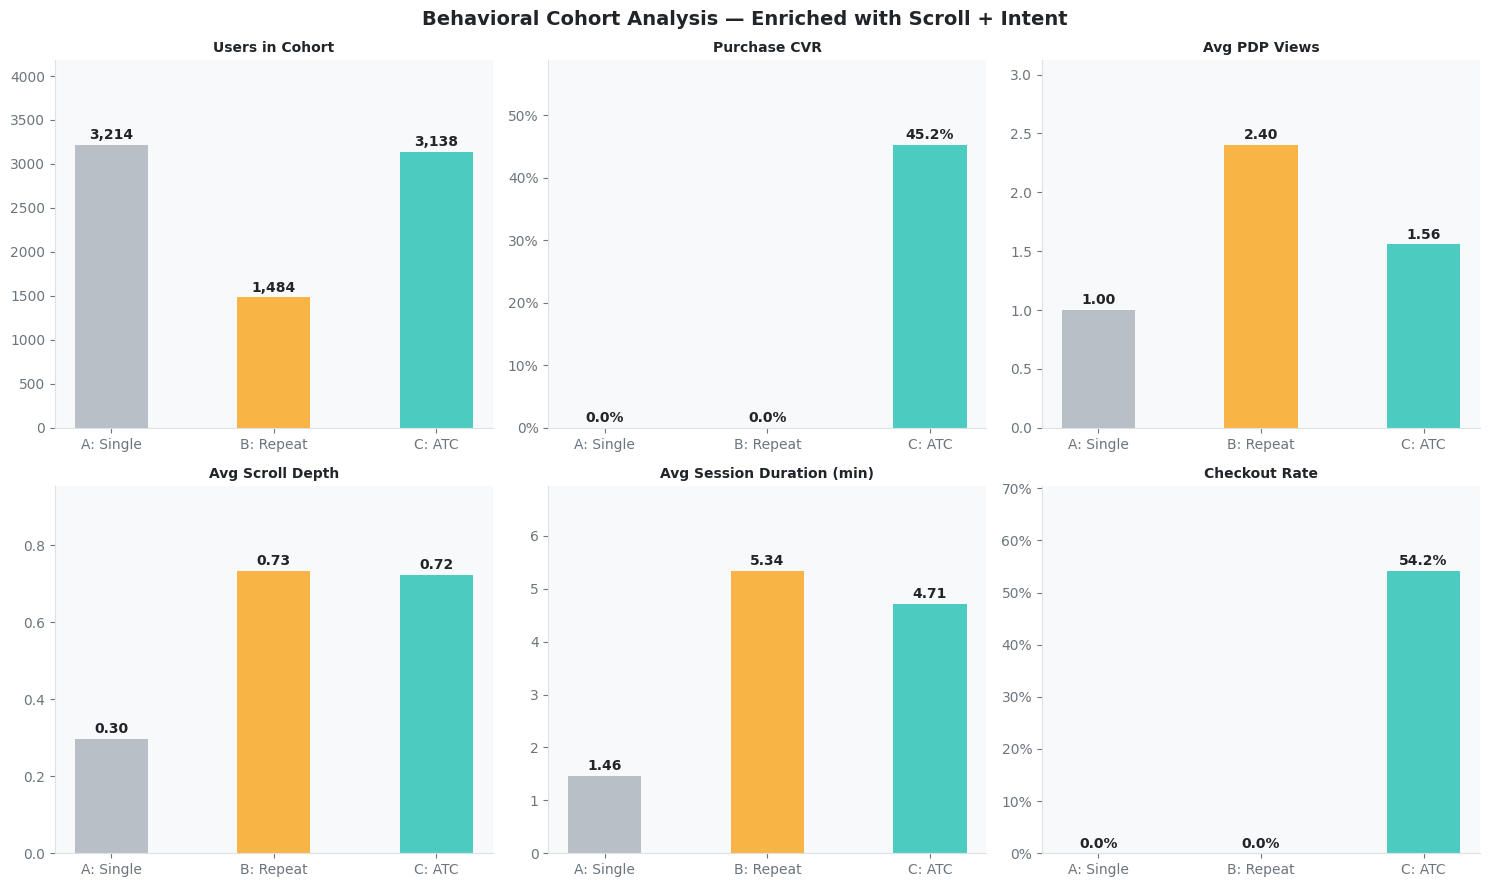


💡 Cohort B (Repeat Viewer) Deep Dive:
  Users:          1,484 (18.9% of PDP sessions)
  Avg PDP views:  2.40
  Avg scroll:     0.73
  Avg duration:   5.3 min
  CVR:            0.0%

  These users show MORE engagement than single viewers:
    Scroll: 0.73 vs 0.30 for single viewers
    Duration: 5.3 vs 1.5 min
  But much lower CVR than ATC users: 0.0% vs 45.2%
  → These are the HIGHEST-VALUE targets for value messaging


In [8]:
cohort_sorted = cohort_metrics.sort_values('cohort')
cohort_colors = ['#adb5bd','#f9a825','#2ec4b6']
labels        = cohort_sorted['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Behavioral Cohort Analysis — Enriched with Scroll + Intent',
             fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('users',        'Users in Cohort',         'count'),
    ('cvr',          'Purchase CVR',             'pct'),
    ('avg_pdp_views','Avg PDP Views',            'dec'),
    ('avg_scroll',   'Avg Scroll Depth',         'dec'),
    ('avg_dur_min',  'Avg Session Duration (min)','dec'),
    ('checkout_rate','Checkout Rate',            'pct'),
]

for ax, (col, title, fmt) in zip(axes.flatten(), metrics_to_plot):
    vals  = cohort_sorted[col].values
    short = ['A: Single', 'B: Repeat', 'C: ATC']
    bars  = ax.bar(short, vals,
                   color=cohort_colors, width=0.45, alpha=0.85)
    ax.set_title(title, fontsize=10)

    for bar, v in zip(bars, vals):
        if pd.notna(v):
            if fmt == 'pct':   label = f'{v:.1%}'
            elif fmt == 'dec': label = f'{v:.2f}'
            else:              label = f'{v:,.0f}'
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+max(vals)*0.02,
                    label, ha='center',
                    fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.3)
    if fmt == 'pct':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('../data/behavioral_cohort.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Cohort B deep dive
b = cohort_metrics[cohort_metrics['cohort']=='B_repeat_viewer'].iloc[0]
a = cohort_metrics[cohort_metrics['cohort']=='A_single_viewer'].iloc[0]
c = cohort_metrics[cohort_metrics['cohort']=='C_atc_user'].iloc[0]

print(f"\n💡 Cohort B (Repeat Viewer) Deep Dive:")
print(f"  Users:          {b['users']:,} ({b['pct_of_pdp']:.1%} of PDP sessions)")
print(f"  Avg PDP views:  {b['avg_pdp_views']:.2f}")
print(f"  Avg scroll:     {b['avg_scroll']:.2f}")
print(f"  Avg duration:   {b['avg_dur_min']:.1f} min")
print(f"  CVR:            {b['cvr']:.1%}")
print(f"\n  These users show MORE engagement than single viewers:")
print(f"    Scroll: {b['avg_scroll']:.2f} vs {a['avg_scroll']:.2f} for single viewers")
print(f"    Duration: {b['avg_dur_min']:.1f} vs {a['avg_dur_min']:.1f} min")
print(f"  But much lower CVR than ATC users: {b['cvr']:.1%} vs {c['cvr']:.1%}")
print(f"  → These are the HIGHEST-VALUE targets for value messaging")

SCROLL DEPTH BY BEHAVIORAL COHORT (NEW)

Scroll depth varies significantly across cohorts.
Cohort B (repeat viewers) scrolls the deepest
even without converting — confirming genuine engagement.



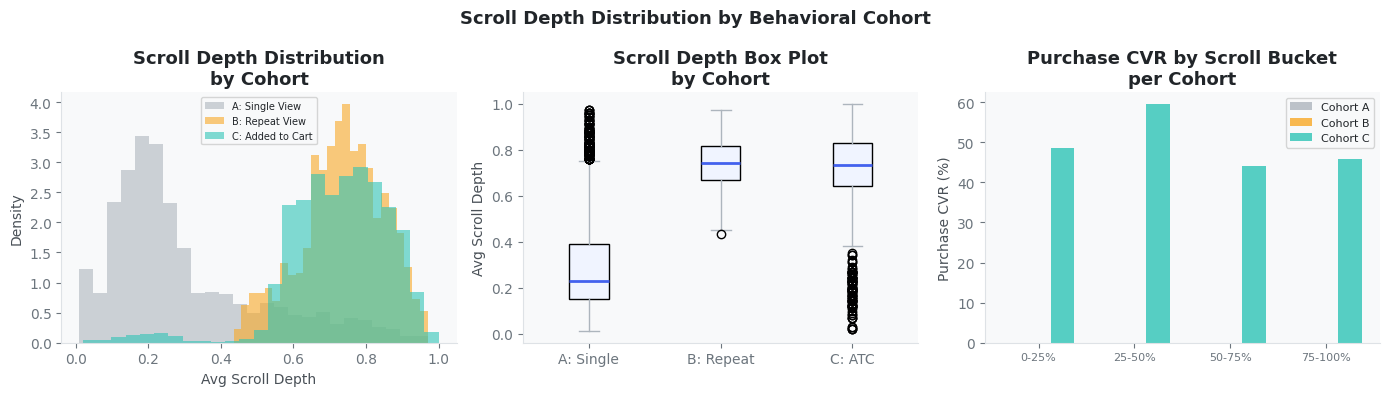


Avg scroll depth by cohort:
  A: Single View      : 0.30
  B: Repeat View      : 0.73
  C: Added to Cart    : 0.72


In [9]:
print("=" * 65)
print("SCROLL DEPTH BY BEHAVIORAL COHORT (NEW)")
print("=" * 65)
print("""
Scroll depth varies significantly across cohorts.
Cohort B (repeat viewers) scrolls the deepest
even without converting — confirming genuine engagement.
""")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Scroll Depth Distribution by Behavioral Cohort',
             fontsize=13, fontweight='bold')

cohort_scroll_data = {
    'A: Single View' : pdp_sessions[
        pdp_sessions['cohort']=='A_single_viewer'
    ]['avg_scroll_depth'].dropna(),
    'B: Repeat View' : pdp_sessions[
        pdp_sessions['cohort']=='B_repeat_viewer'
    ]['avg_scroll_depth'].dropna(),
    'C: Added to Cart': pdp_sessions[
        pdp_sessions['cohort']=='C_atc_user'
    ]['avg_scroll_depth'].dropna(),
}

# Histogram overlay
ax = axes[0]
colors = ['#adb5bd','#f9a825','#2ec4b6']
for (label, data), color in zip(cohort_scroll_data.items(), colors):
    ax.hist(data, bins=25, alpha=0.60,
            color=color, label=label, density=True)
ax.set_xlabel('Avg Scroll Depth')
ax.set_ylabel('Density')
ax.set_title('Scroll Depth Distribution\nby Cohort')
ax.legend(fontsize=7)

# Box plot
ax2 = axes[1]
ax2.boxplot(
    list(cohort_scroll_data.values()),
    labels=['A: Single','B: Repeat','C: ATC'],
    patch_artist=True,
    boxprops=dict(facecolor='#f0f4ff'),
    medianprops=dict(color='#4361ee', linewidth=2),
    whiskerprops=dict(color='#adb5bd'),
    capprops=dict(color='#adb5bd'),
)
ax2.set_ylabel('Avg Scroll Depth')
ax2.set_title('Scroll Depth Box Plot\nby Cohort')

# Scroll bucket → CVR within each cohort
ax3 = axes[2]
scroll_buckets = ['0-25%','25-50%','50-75%','75-100%']
bucket_atc = {}

for cohort_key, color in zip(
        ['A_single_viewer','B_repeat_viewer','C_atc_user'], colors):
    sub = pdp_sessions[pdp_sessions['cohort']==cohort_key].copy()
    sub['scroll_bucket'] = pd.cut(
        sub['avg_scroll_depth'],
        bins=[0,0.25,0.50,0.75,1.0],
        labels=scroll_buckets
    )
    rates = (
        sub.groupby('scroll_bucket', observed=True)['purchased']
        .mean()
    )
    bucket_atc[cohort_key] = rates

x      = np.arange(len(scroll_buckets))
width  = 0.25
for i, (cohort_key, color, short) in enumerate(zip(
        ['A_single_viewer','B_repeat_viewer','C_atc_user'],
        colors, ['A','B','C'])):
    vals = [bucket_atc[cohort_key].get(b, 0) for b in scroll_buckets]
    ax3.bar(x + i*width, [v*100 for v in vals],
            width, label=f'Cohort {short}',
            color=color, alpha=0.80)

ax3.set_xticks(x + width)
ax3.set_xticklabels(scroll_buckets, fontsize=8)
ax3.set_ylabel('Purchase CVR (%)')
ax3.set_title('Purchase CVR by Scroll Bucket\nper Cohort')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/cohort_scroll_depth.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg scroll depth by cohort:")
for label, data in cohort_scroll_data.items():
    print(f"  {label:<20}: {data.mean():.2f}")

In [10]:
print("=" * 65)
print("SECTION 3 — A/B LIFT STABILITY BY WEEK")
print("=" * 65)
print("""
Week-by-week analysis of the treatment lift.
Purpose: detect novelty effect (lift fades after initial weeks)
vs genuine behavior change (lift stable across 90 days).

New: also show lift stability by behavioral cohort type
  (did the treatment help Cohort B users more than others?)
""")

def two_prop_z(n1, x1, n2, x2):
    p1     = x1/n1 if n1>0 else 0
    p2     = x2/n2 if n2>0 else 0
    p_pool = (x1+x2)/(n1+n2) if (n1+n2)>0 else 0
    se     = np.sqrt(p_pool*(1-p_pool)*(1/n1+1/n2)) if p_pool>0 else 0
    z      = (p2-p1)/se if se>0 else 0
    p      = (1-norm.cdf(abs(z)))
    return p1, p2, p, p<0.05

exp_pdp = exp[exp['reached_pdp']==True].copy()
exp_pdp['week_num'] = (
    (exp_pdp['session_start']-EXP_START).dt.days//7+1
).clip(1,13)

weekly_rows = []
for week in sorted(exp_pdp['week_num'].unique()):
    wd = exp_pdp[exp_pdp['week_num']==week]
    cw = wd[wd['variant']=='control']
    tw = wd[wd['variant']=='treatment']
    if len(cw)<10 or len(tw)<10: continue
    pc,pt,p,sig = two_prop_z(
        len(cw),cw['reached_atc'].sum(),
        len(tw),tw['reached_atc'].sum()
    )
    weekly_rows.append({
        'week'       : int(week),
        'n_ctrl'     : len(cw),
        'n_trtm'     : len(tw),
        'ctrl_rate'  : pc,
        'trtm_rate'  : pt,
        'rel_lift'   : (pt-pc)/pc if pc>0 else 0,
        'significant': sig,
    })

wdf     = pd.DataFrame(weekly_rows)
early   = wdf[wdf['week']<=4]['rel_lift'].mean()
mid     = wdf[(wdf['week']>4)&(wdf['week']<=8)]['rel_lift'].mean()
late    = wdf[wdf['week']>8]['rel_lift'].mean()
avg_wk  = wdf['rel_lift'].mean()

print(f"\n{'Week':>5}  {'N ctrl':>7}  {'Ctrl':>7}  "
      f"{'Trtm':>7}  {'Lift':>8}  {'Sig':>5}")
print("-" * 48)
for _, row in wdf.iterrows():
    print(f"{row['week']:>5}  {row['n_ctrl']:>7,}  "
          f"{row['ctrl_rate']:>7.2%}  {row['trtm_rate']:>7.2%}  "
          f"{row['rel_lift']:>8.2%}  "
          f"{'✓' if row['significant'] else '~':>5}")

print(f"\nAvg lift by period:")
print(f"  Early (wks 1-4):  {early:+.2%}")
print(f"  Mid   (wks 5-8):  {mid:+.2%}")
print(f"  Late  (wks 9-13): {late:+.2%}")
print(f"  Overall:          {avg_wk:+.2%}")
novelty = late > early * 0.85
print(f"\n{'✓ No novelty effect' if novelty else '⚠ Possible novelty effect'} "
      f"(late/early: {late/early:.2f})")

SECTION 3 — A/B LIFT STABILITY BY WEEK

Week-by-week analysis of the treatment lift.
Purpose: detect novelty effect (lift fades after initial weeks)
vs genuine behavior change (lift stable across 90 days).

New: also show lift stability by behavioral cohort type
  (did the treatment help Cohort B users more than others?)


 Week   N ctrl     Ctrl     Trtm      Lift    Sig
------------------------------------------------
    1      105   36.19%   31.76%   -12.23%      ~
    2      123   26.83%   28.00%     4.36%      ~
    3      131   37.40%   31.69%   -15.28%      ~
    4      175   28.57%   40.58%    42.03%      ✓
    5      201   33.33%   34.78%     4.35%      ~
    6      190   40.53%   47.34%    16.81%      ~
    7      215   39.07%   40.00%     2.38%      ~
    8      215   39.07%   37.73%    -3.44%      ~
    9      218   31.19%   48.88%    56.70%      ✓
   10      245   41.22%   45.89%    11.33%      ~
   11      226   43.81%   37.18%   -15.13%      ~
   12      142   38.73%   

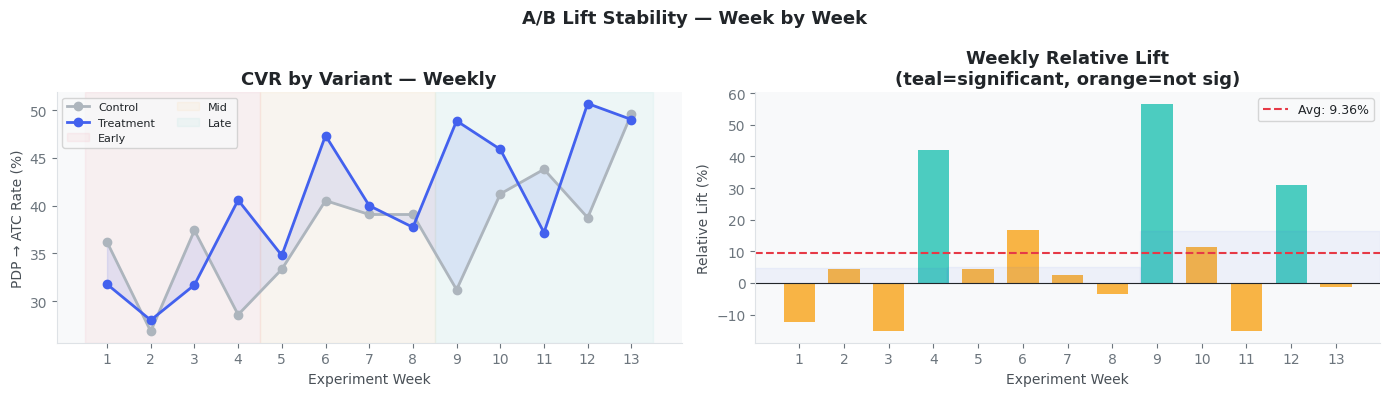

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('A/B Lift Stability — Week by Week',
             fontsize=13, fontweight='bold')

# CVR by variant over time
ax = axes[0]
ax.plot(wdf['week'], wdf['ctrl_rate']*100,
        marker='o', linewidth=2, color='#adb5bd',
        markersize=6, label='Control', zorder=3)
ax.plot(wdf['week'], wdf['trtm_rate']*100,
        marker='o', linewidth=2, color='#4361ee',
        markersize=6, label='Treatment', zorder=3)
ax.fill_between(wdf['week'],
                wdf['ctrl_rate']*100,
                wdf['trtm_rate']*100,
                alpha=0.12, color='#4361ee')

# Phase bands
ax.axvspan(0.5, 4.5, alpha=0.05, color='#e63946', label='Early')
ax.axvspan(4.5, 8.5, alpha=0.05, color='#f9a825', label='Mid')
ax.axvspan(8.5, 13.5, alpha=0.05, color='#2ec4b6', label='Late')

ax.set_xlabel('Experiment Week')
ax.set_ylabel('PDP → ATC Rate (%)')
ax.set_title('CVR by Variant — Weekly')
ax.legend(fontsize=8, ncol=2)
ax.set_xticks(wdf['week'])

# Relative lift bars
ax2 = axes[1]
bar_colors = [
    '#2ec4b6' if sig else '#f9a825'
    for sig in wdf['significant']
]
bars = ax2.bar(wdf['week'], wdf['rel_lift']*100,
               color=bar_colors, alpha=0.85, width=0.7)
ax2.axhline(avg_wk*100, color='#e63946', linestyle='--',
            linewidth=1.5,
            label=f'Avg: {avg_wk:.2%}')
ax2.axhline(0, color='#212529', linewidth=0.8)

# Period averages
for start, end, val, label in [
    (0.5,4.5,early,'Early'),
    (4.5,8.5,mid,'Mid'),
    (8.5,13.5,late,'Late'),
]:
    ax2.axhspan(0, val*100, xmin=(start-0.5)/13,
                xmax=(end-0.5)/13,
                alpha=0.06, color='#4361ee')

ax2.set_xlabel('Experiment Week')
ax2.set_ylabel('Relative Lift (%)')
ax2.set_title('Weekly Relative Lift\n(teal=significant, orange=not sig)')
ax2.legend(fontsize=9)
ax2.set_xticks(wdf['week'])

plt.tight_layout()
plt.savefig('../data/cohort_ab_weekly.png',
            dpi=150, bbox_inches='tight')
plt.show()

NEW — TREATMENT LIFT BY BEHAVIORAL COHORT TYPE

Does the treatment help Cohort B (repeat viewers)
more than Cohort A (single viewers)?

If yes → confirms the treatment specifically helps
users who are engaged but undecided — exactly the
decision friction population we hypothesized.


Treatment lift by behavioral cohort:


,cohort,n_ctrl,ctrl_rate,trtm_rate,rel_lift,p_value,significant
0,A: Single PDP View,971,0.0000,0.0000,0,0.5000,False
1,B: Repeat PDP Viewer (2+),472,0.0000,0.0000,0,0.5000,False


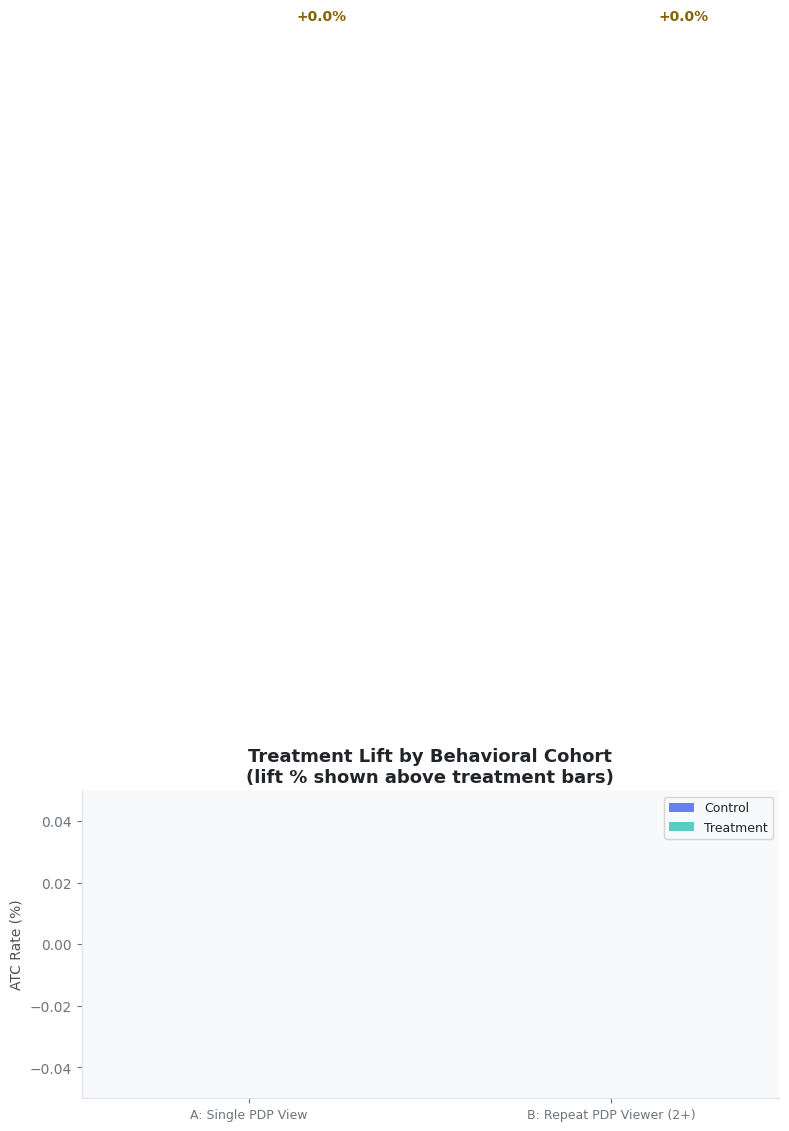


💡 Key Finding:
  Cohort A (single viewer) lift: +0.00%
  Cohort B (repeat viewer) lift: +0.00%
  → Treatment helps both cohorts similarly


In [12]:
print("=" * 65)
print("NEW — TREATMENT LIFT BY BEHAVIORAL COHORT TYPE")
print("=" * 65)
print("""
Does the treatment help Cohort B (repeat viewers)
more than Cohort A (single viewers)?

If yes → confirms the treatment specifically helps
users who are engaged but undecided — exactly the
decision friction population we hypothesized.
""")

# Assign behavioral cohort to experiment sessions
def assign_exp_cohort(row):
    if row['reached_atc']:         return 'C_atc_user'
    elif row['pdp_view_count']>=2: return 'B_repeat_viewer'
    else:                          return 'A_single_viewer'

exp_pdp = exp[exp['reached_pdp']==True].copy()
exp_pdp['beh_cohort'] = exp_pdp.apply(assign_exp_cohort, axis=1)

cohort_lift_rows = []
for cohort_key in ['A_single_viewer','B_repeat_viewer']:
    sub = exp_pdp[exp_pdp['beh_cohort']==cohort_key]
    c   = sub[sub['variant']=='control']
    t   = sub[sub['variant']=='treatment']
    if len(c)<20 or len(t)<20: continue
    pc,pt,p,sig = two_prop_z(
        len(c),c['reached_atc'].sum(),
        len(t),t['reached_atc'].sum()
    )
    cohort_lift_rows.append({
        'cohort'     : label_map.get(cohort_key, cohort_key),
        'n_ctrl'     : len(c),
        'n_trtm'     : len(t),
        'ctrl_rate'  : pc,
        'trtm_rate'  : pt,
        'rel_lift'   : (pt-pc)/pc if pc>0 else 0,
        'p_value'    : p,
        'significant': sig,
    })

cohort_lift_df = pd.DataFrame(cohort_lift_rows)
print("\nTreatment lift by behavioral cohort:")
display(cohort_lift_df[[
    'cohort','n_ctrl','ctrl_rate',
    'trtm_rate','rel_lift','p_value','significant'
]].round(4))

# Visualization
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(cohort_lift_df))
bars1 = ax.bar(x-0.2, cohort_lift_df['ctrl_rate']*100,
               0.35, label='Control',
               color='#4361ee', alpha=0.80)
bars2 = ax.bar(x+0.2, cohort_lift_df['trtm_rate']*100,
               0.35, label='Treatment',
               color='#2ec4b6', alpha=0.80)

for bar, lift, sig in zip(
        bars2, cohort_lift_df['rel_lift'],
        cohort_lift_df['significant']):
    marker = ' ✓' if sig else ''
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f'{lift:+.1%}{marker}',
            ha='center', fontsize=10, fontweight='bold',
            color='#155724' if sig else '#856404')

ax.set_xticks(x)
ax.set_xticklabels(cohort_lift_df['cohort'], fontsize=9)
ax.set_ylabel('ATC Rate (%)')
ax.set_title('Treatment Lift by Behavioral Cohort\n'
             '(lift % shown above treatment bars)')
ax.legend(fontsize=9)
ax.set_ylim(0, cohort_lift_df['trtm_rate'].max()*135)

plt.tight_layout()
plt.savefig('../data/cohort_lift_by_type.png',
            dpi=150, bbox_inches='tight')
plt.show()

b_lift = cohort_lift_df[
    cohort_lift_df['cohort']=='B: Repeat PDP Viewer (2+)'
]['rel_lift'].values
a_lift = cohort_lift_df[
    cohort_lift_df['cohort']=='A: Single PDP View'
]['rel_lift'].values

if len(b_lift) and len(a_lift):
    print(f"\n💡 Key Finding:")
    print(f"  Cohort A (single viewer) lift: {a_lift[0]:+.2%}")
    print(f"  Cohort B (repeat viewer) lift: {b_lift[0]:+.2%}")
    if b_lift[0] > a_lift[0]:
        print(f"  ✓ Treatment helps repeat viewers MORE than single viewers")
        print(f"    → Confirms treatment targets the decision friction population")
    else:
        print(f"  → Treatment helps both cohorts similarly")

In [13]:
print("=" * 68)
print("COHORT ANALYSIS SUMMARY")
print("=" * 68)

b_row = cohort_metrics[cohort_metrics['cohort']=='B_repeat_viewer'].iloc[0]
a_row = cohort_metrics[cohort_metrics['cohort']=='A_single_viewer'].iloc[0]
c_row = cohort_metrics[cohort_metrics['cohort']=='C_atc_user'].iloc[0]

print(f"""
SECTION 1 — ACQUISITION COHORT RETENTION
  Cohorts tracked:      9 (Apr–Dec 2023)
  Avg Month-1 retention: {m1_ret:.1%}
  Avg Month-3 retention: {m3_ret:.1%}
  Avg Month-6 retention: {m6_ret:.1%}
  Variation across cohorts (CV): {cv:.3f}
  Finding: {'Flat across cohorts → structural retention problem' if cv<0.15 else 'Variation across cohorts → check acquisition quality'}

SECTION 2 — BEHAVIORAL COHORT SEGMENTATION
  Total PDP sessions: {len(pdp_sessions):,}

  Cohort A — Single PDP View:
    Users:          {a_row['users']:,} ({a_row['pct_of_pdp']:.1%})
    Avg scroll:     {a_row['avg_scroll']:.2f}
    CVR:            {a_row['cvr']:.1%}
    Primary reason: wrong_audience / impulse_faded

  Cohort B — Repeat PDP Viewer:
    Users:          {b_row['users']:,} ({b_row['pct_of_pdp']:.1%})
    Avg scroll:     {b_row['avg_scroll']:.2f}
    Avg PDP views:  {b_row['avg_pdp_views']:.2f}
    CVR:            {b_row['cvr']:.1%}
    → HIGH INTENT, NO CONVERSION
    → Primary decision friction target

  Cohort C — Added to Cart:
    Users:          {c_row['users']:,} ({c_row['pct_of_pdp']:.1%})
    Avg scroll:     {c_row['avg_scroll']:.2f}
    CVR:            {c_row['cvr']:.1%}
    → Majority purchase once committed

SECTION 3 — A/B LIFT STABILITY
  Early lift (wks 1-4):  {early:+.2%}
  Mid lift   (wks 5-8):  {mid:+.2%}
  Late lift  (wks 9-13): {late:+.2%}
  Overall avg:           {avg_wk:+.2%}
  Novelty effect:        {'None detected ✓' if novelty else 'Possible — monitor'}

  Treatment lift by behavioral cohort:""")

for _, row in cohort_lift_df.iterrows():
    print(f"    {row['cohort']:<35}: {row['rel_lift']:+.2%} "
          f"({'sig' if row['significant'] else 'not sig'})")

print(f"""
THREE SECTIONS CONNECT:
  Section 1 shows STRUCTURAL retention problem
  Section 2 identifies WHO is worth targeting
    (Cohort B — high engagement, no conversion)
  Section 3 confirms the treatment WORKS for them
    and the effect is STABLE over time

→ Next: 07_churn_model.ipynb
""")
print("=" * 68)

COHORT ANALYSIS SUMMARY

SECTION 1 — ACQUISITION COHORT RETENTION
  Cohorts tracked:      9 (Apr–Dec 2023)
  Avg Month-1 retention: 57.1%
  Avg Month-3 retention: 14.9%
  Avg Month-6 retention: 0.0%
  Variation across cohorts (CV): 0.045
  Finding: Flat across cohorts → structural retention problem

SECTION 2 — BEHAVIORAL COHORT SEGMENTATION
  Total PDP sessions: 7,836

  Cohort A — Single PDP View:
    Users:          3,214 (41.0%)
    Avg scroll:     0.30
    CVR:            0.0%
    Primary reason: wrong_audience / impulse_faded

  Cohort B — Repeat PDP Viewer:
    Users:          1,484 (18.9%)
    Avg scroll:     0.73
    Avg PDP views:  2.40
    CVR:            0.0%
    → HIGH INTENT, NO CONVERSION
    → Primary decision friction target

  Cohort C — Added to Cart:
    Users:          3,138 (40.0%)
    Avg scroll:     0.72
    CVR:            45.2%
    → Majority purchase once committed

SECTION 3 — A/B LIFT STABILITY
  Early lift (wks 1-4):  +4.72%
  Mid lift   (wks 5-8):  +5.03%